# Create WecOptTool Model for the Marson WEC concept

In [5]:
import logging
import numpy as np
import capytaine as cpt
from capytaine.io import mesh_writers
import pygmsh
import gmsh
import vtk
import matplotlib.pyplot as plt
import os
import xarray as xr
from capytaine.io.meshio import load_from_meshio

logging.basicConfig(level=logging.INFO,format="%(levelnames)s:\t%(message)s")

#### WEC geometry mesh
Now we will create a surface mesh for the WEC hull and store it using the `FloatingBody` object from Capytaine.

In [6]:
# provided by OSU
float_mass_properties = {
    'mass': 248.721,
    'CG': [0.01, 0, 0.06],
    'MOI': [66.1686, 65.3344, 17.16],
}

spar_mass_properties = {
    'mass': 175.536,
    'CG': [0, 0, -1.3],
    'MOI': [253.6344, 250.4558, 12.746],
}

water_depth = 2.7 # depth of wave flume



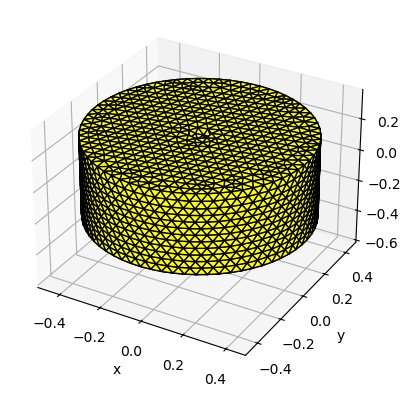

In [7]:
# mesh
mesh_size_factor = 0.3
r1 = 1.0/2  # top radius
r2 = 0.4/2  # bottom radius
h1 = 0.5  
h2 = 0.21
freeboard = 0.3
r3 = 0.05  # hole radius
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', mesh_size_factor)
    cyl = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    cone = geom.add_cone([0, 0, -h1], [0, 0, -h2], r1, r2)
    geom.translate(cyl, [0, 0, freeboard])
    geom.translate(cone, [0, 0, freeboard]) 
    tmp = geom.boolean_union([cyl, cone])
    bar = geom.add_cylinder([0, 0, 10], [0,0,-20], r3)
    geom.boolean_difference(tmp, bar)
    mesh_float = geom.generate_mesh()

# lid
mesh_obj_float = load_from_meshio(mesh_float, 'float')
lid_mesh = mesh_obj_float.generate_lid(z=-1e-2)

# floating body
float_fb = cpt.FloatingBody(mesh=mesh_obj_float, lid_mesh=lid_mesh, name="float")

float_fb = float_fb.translate_z(-float_mass_properties['CG'][2])
float_fb = float_fb.translate_x(-float_mass_properties['CG'][0])

# show
float_fb.show_matplotlib()

cpt.io.mesh_writers.write_STL('float.stl',float_fb.mesh.vertices, float_fb.mesh.faces)

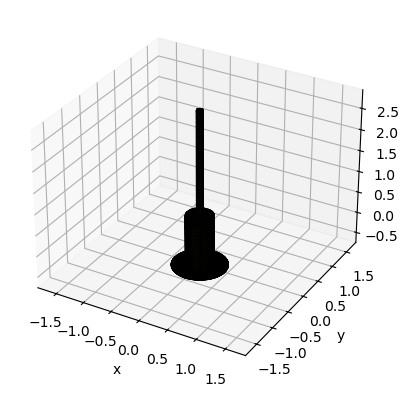

In [8]:
# mesh
mesh_size_factor = 0.1
r1 = 0.45/2  # body
r2 = 0.45  # plate
r3 = 0.10/2  # bar
h1 = 1.20  
h2 = 0.01
h3a = 3.684 - 2.05
submergence = 2.05 - h1 - h2

with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', mesh_size_factor)
    body = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    geom.translate(body, [0, 0, -submergence])
    plate = geom.add_cylinder([0, 0, 0], [0, 0, -h2], r2)
    geom.translate(plate, [0, 0, -(submergence+h1)])
    bar = geom.add_cylinder([0, 0, h3a], [0, 0, -(h3a+submergence)], r3)
    geom.boolean_union([bar, body, plate])
    mesh_spar = geom.generate_mesh()

# lid
mesh_obj_spar = load_from_meshio(mesh_spar, 'spar')
lid_mesh = mesh_obj_spar.generate_lid(z=-1e-2)

# floating body
spar_fb = cpt.FloatingBody(mesh=mesh_obj_spar, lid_mesh=lid_mesh, name="spar")

spar_fb = spar_fb.translate_z(-spar_mass_properties['CG'][2])

# show
spar_fb.show_matplotlib()

cpt.io.mesh_writers.write_STL('spar.stl',spar_fb.mesh.vertices, spar_fb.mesh.faces)
